# 第11节：模型水印与版权保护

本节关注“如何证明模型归属、如何抵抗常见模型改造、如何跟踪使用”。

覆盖内容：

1) **水印嵌入与提取（white-box）**：把一串签名比特嵌入到权重子集，使得拥有者在拿到模型权重时可提取并验证。

2) **鲁棒性分析**：模拟剪枝、量化、轻微微调等常见改造，观察水印提取正确率与模型精度的变化。

3) **模型指纹（fingerprint）**：在不暴露训练数据的条件下，用哈希指纹与“探针集输出摘要”作为可复核证据。

4) **使用跟踪机制（工程视角）**：API 返回策略、审计日志、令牌绑定与可追溯记录的基本设计。

## 0. 路径约定（与前几节一致）

notebooks 作为运行目录，data 与 notebooks 同级。

```python
PROJECT_ROOT = Path.cwd().resolve().parent
```

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
MODELS_DIR = PROJECT_ROOT / 'models'
ART_DIR = PROJECT_ROOT / 'artifacts'

print('CWD:', Path.cwd())
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR exists:', DATA_DIR.exists(), '|', DATA_DIR)
print('MODELS_DIR exists:', MODELS_DIR.exists(), '|', MODELS_DIR)
print('ART_DIR exists:', ART_DIR.exists(), '|', ART_DIR)

device = torch.device('cpu')
print('torch:', torch.__version__, 'device:', device)


CWD: C:\Users\wingl\PycharmProjects\adversarialmeow\notebooks
PROJECT_ROOT: C:\Users\wingl\PycharmProjects\adversarialmeow
DATA_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\data
MODELS_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\models
ART_DIR exists: True | C:\Users\wingl\PycharmProjects\adversarialmeow\artifacts
torch: 2.10.0+cpu device: cpu


## 1. 数据与模型（离线可复现）

优先读取：
- `data/digits.npz`（X, y）
- 或 `data/X.npy` + `data/y.npy`

没有则回退到 sklearn digits（8×8 灰度）。

模型：简易 MLP（与前几节保持一致），用于展示水印方法流程。

In [8]:
def load_course_data(data_dir: Path):
    npz_path = data_dir / 'digits.npz'
    if npz_path.exists():
        arr = np.load(npz_path)
        X = arr['X'].astype(np.float32)
        y = arr['y'].astype(np.int64)
        return X, y, f'Loaded local NPZ: {npz_path.name}'

    x_npy = data_dir / 'X.npy'
    y_npy = data_dir / 'y.npy'
    if x_npy.exists() and y_npy.exists():
        X = np.load(x_npy).astype(np.float32)
        y = np.load(y_npy).astype(np.int64)
        return X, y, f'Loaded local NPY: {x_npy.name}, {y_npy.name}'

    from sklearn.datasets import load_digits
    ds = load_digits()
    X = ds.data.astype(np.float32)
    y = ds.target.astype(np.int64)
    return X, y, 'Loaded sklearn digits fallback'

X, y, info = load_course_data(DATA_DIR)
print(info)
x_min, x_max = float(X.min()), float(X.max())
if x_max > 1.0:
    X01 = (X - x_min) / (x_max - x_min + 1e-12)
else:
    X01 = np.clip(X, 0.0, 1.0)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X01, y, test_size=0.25, random_state=42, stratify=y
)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32, device=device)
y_test_t  = torch.tensor(y_test,  dtype=torch.long, device=device)

class MLP(nn.Module):
    def __init__(self, in_dim=64, hidden=128, emb_dim=64, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, emb_dim)
        self.fc3 = nn.Linear(emb_dim, num_classes)

    def feature(self, x):
        x = F.relu(self.fc1(x))
        z = F.relu(self.fc2(x))
        return z

    def forward(self, x):
        z = self.feature(x)
        return self.fc3(z)

def accuracy(model, X, y, batch=256):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb, yb = X[i:i+batch], y[i:i+batch]
            pred = model(xb).argmax(dim=1)
            correct += int((pred == yb).sum().item())
            total += int(len(xb))
    return correct / max(total, 1)

def train_model(model, X, y, epochs=10, lr=1e-3, batch=256):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=X.device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if ep == 1 or ep == epochs or ep % 2 == 0:
            print(f'Epoch {ep:02d} | train={accuracy(model,X,y):.4f} | test={accuracy(model,X_test_t,y_test_t):.4f}')

MODELS_DIR.mkdir(parents=True, exist_ok=True)
base_path = MODELS_DIR / 'clean_model_tofinepruning.pt'

base_model = MLP().to(device)
if base_path.exists():
    base_model.load_state_dict(torch.load(base_path, map_location=device))
    print('Loaded:', base_path)
else:
    print('Training baseline...')
    train_model(base_model, X_train_t, y_train_t, epochs=10)
    torch.save(base_model.state_dict(), base_path)
    print('Saved:', base_path)

print('Baseline clean acc:', accuracy(base_model, X_test_t, y_test_t))


Loaded local NPZ: digits.npz
Loaded: C:\Users\wingl\PycharmProjects\adversarialmeow\models\clean_model_tofinepruning.pt
Baseline clean acc: 0.8422222222222222


## 2. 水印（white-box）方案：权重子集嵌入签名比特

### 2.1 思路
选择一组参数位置（由私钥 seed 决定），把签名比特映射成目标权重值的符号/区间。
训练时加入一个水印正则项，使这些权重靠近目标。

### 2.2 优点与限制
- 优点：提取简单，适合交付/验收时做权重级归属证明。
- 限制：若模型被强烈再训练或重参数化，水印可能退化；因此需要鲁棒性评估。


In [9]:
def make_signature_bits(n_bits=128, seed=2026):
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=n_bits, endpoint=False).astype(np.int64)
    return bits

def select_weight_positions(state_dict, n_bits=128, seed=2026):
    """从所有 2D 权重矩阵中选择 n_bits 个位置作为水印载体（私钥控制）。"""
    rng = np.random.default_rng(seed)
    candidates = []
    for k, v in state_dict.items():
        if v.ndim == 2 and 'weight' in k:
            rows, cols = v.shape
            # 抽一些候选位置（避免遍历全矩阵）
            for _ in range(min(4000, rows*cols)):
                i = int(rng.integers(0, rows))
                j = int(rng.integers(0, cols))
                candidates.append((k, i, j))
    rng.shuffle(candidates)
    return candidates[:n_bits]

def embed_watermark(model, X, y, bits, positions, lam=0.02, target_mag=0.6, epochs=4, lr=1e-3, batch=256):
    """嵌入：任务损失 + 水印正则。
    bits=0/1 映射到目标权重：[-target_mag, +target_mag]
    """
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    bit_targets = torch.tensor((bits*2 - 1) * target_mag, dtype=torch.float32, device=device)  # 0->-mag, 1->+mag

    # 建立位置到参数张量的访问
    name_to_param = dict(model.named_parameters())
    # 位置一般在 state_dict 的 'fcX.weight' 上，named_parameters 同名

    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=device)
        for i0 in range(0, len(X), batch):
            idx = perm[i0:i0+batch]
            xb, yb = X[idx], y[idx]
            logits = model(xb)
            loss_task = F.cross_entropy(logits, yb)

            # watermark loss
            w_vals = []
            for (name, r, c) in positions:
                w = name_to_param[name]
                w_vals.append(w[r, c])
            w_vals = torch.stack(w_vals)
            loss_wm = F.mse_loss(w_vals, bit_targets)

            loss = loss_task + lam * loss_wm
            opt.zero_grad(); loss.backward(); opt.step()

        if ep == 1 or ep == epochs:
            print(f'WM Epoch {ep:02d} | clean acc={accuracy(model, X_test_t, y_test_t):.4f} | loss_wm={float(loss_wm.item()):.6f}')

    return model

def extract_watermark(model, positions, threshold=0.0):
    name_to_param = dict(model.named_parameters())
    vals = []
    for (name, r, c) in positions:
        v = float(name_to_param[name][r, c].detach().cpu().item())
        vals.append(v)
    vals = np.array(vals, dtype=np.float32)
    bits_hat = (vals > threshold).astype(np.int64)
    return bits_hat, vals

def bit_accuracy(bits, bits_hat):
    bits = np.asarray(bits).astype(np.int64)
    bits_hat = np.asarray(bits_hat).astype(np.int64)
    return float((bits == bits_hat).mean())

# 生成水印签名（拥有者私钥）
owner_seed = 202611  # 教学用示例：真实场景应由机构密钥管理
bits = make_signature_bits(n_bits=128, seed=owner_seed)

# 选择嵌入位置（同样由 seed 控制）
positions = select_weight_positions(base_model.state_dict(), n_bits=len(bits), seed=owner_seed)
print('selected positions:', len(positions))

# 基线提取（未嵌入时）
bits0_hat, _ = extract_watermark(base_model, positions)
print('baseline bit-acc (should be ~0.5):', bit_accuracy(bits, bits0_hat))


selected positions: 128
baseline bit-acc (should be ~0.5): 0.5


## 3. 嵌入水印并保存

我们从基线模型复制一份，进行少量训练嵌入水印。
水印强度由：
- `lam`（水印正则权重）
- `target_mag`（目标权重幅度）
- `epochs`（嵌入训练轮数）

控制。一般希望：
- clean acc 变化很小
- bit-acc 接近 1.0


In [10]:
wm_model = MLP().to(device)
wm_model.load_state_dict(base_model.state_dict())

wm_model = embed_watermark(
    wm_model,
    X_train_t,
    y_train_t,
    bits=bits,
    positions=positions,
    lam=0.04,
    target_mag=0.7,
    epochs=4,
    lr=1e-3
)

bits_hat, vals = extract_watermark(wm_model, positions)
print('WM model clean acc:', accuracy(wm_model, X_test_t, y_test_t))
print('WM bit-acc:', bit_accuracy(bits, bits_hat))

wm_path = MODELS_DIR / 'watermarked_model.pt'
torch.save(wm_model.state_dict(), wm_path)
print('Saved:', wm_path)

# 保存水印凭证（仅保存公开部分：hash/承诺；seed 属于私钥不应公开）
ART_DIR.mkdir(parents=True, exist_ok=True)
cred_path = ART_DIR / 'watermark_credential.json'
credential = {
    'scheme': 'weight_subset_sign',
    'n_bits': int(len(bits)),
    'public_note': 'Ownership proof requires private seed to select positions and interpret bits.'
}
cred_path.write_text(json.dumps(credential, ensure_ascii=False, indent=2), encoding='utf-8')
print('Saved credential:', cred_path)


WM Epoch 01 | clean acc=0.8578 | loss_wm=0.480422
WM Epoch 04 | clean acc=0.8822 | loss_wm=0.472285
WM model clean acc: 0.8822222222222222
WM bit-acc: 0.578125
Saved: C:\Users\wingl\PycharmProjects\adversarialmeow\models\watermarked_model.pt
Saved credential: C:\Users\wingl\PycharmProjects\adversarialmeow\artifacts\watermark_credential.json


## 4. 鲁棒性分析：剪枝 / 量化 / 轻微微调

我们模拟三类常见“模型改造”对水印的影响：

1) **剪枝**：将绝对值较小的一部分权重置零。

2) **量化**：将权重四舍五入到指定小数位（模拟低精度存储/部署）。

3) **干净微调**：用少量干净数据再训练几轮（模拟领域迁移或继续训练）。

输出两条曲线：
- clean acc
- watermark bit-acc


In [11]:
def clone_model(model):
    m = MLP().to(device)
    m.load_state_dict(model.state_dict())
    return m

def prune_global_by_magnitude(model, prune_ratio=0.2):
    with torch.no_grad():
        ws = []
        for n, p in model.named_parameters():
            if 'weight' in n:
                ws.append(p.view(-1).abs().cpu().numpy())
        allw = np.concatenate(ws)
        thr = np.quantile(allw, prune_ratio)

        for n, p in model.named_parameters():
            if 'weight' in n:
                mask = (p.abs() >= thr).to(p.dtype)
                p.mul_(mask)
    return model

def quantize_weights(model, decimals=2):
    with torch.no_grad():
        for n, p in model.named_parameters():
            p.copy_(torch.round(p * (10**decimals)) / (10**decimals))
    return model

def finetune_clean(model, X, y, epochs=2, lr=5e-4, batch=256):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        perm = torch.randperm(len(X), device=device)
        for i in range(0, len(X), batch):
            idx = perm[i:i+batch]
            xb, yb = X[idx], y[idx]
            loss = F.cross_entropy(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return model

def eval_wm(model, label):
    acc = accuracy(model, X_test_t, y_test_t)
    bits_hat, _ = extract_watermark(model, positions)
    bacc = bit_accuracy(bits, bits_hat)
    print(f'{label:>24s} | clean acc={acc:.4f} | bit-acc={bacc:.4f}')
    return acc, bacc

print('== Robustness: baseline watermarked ==')
eval_wm(wm_model, 'WM(original)')

records = []

# 1) pruning sweep
for r in [0.05, 0.10, 0.20, 0.30, 0.40]:
    m = clone_model(wm_model)
    prune_global_by_magnitude(m, prune_ratio=r)
    acc, bacc = eval_wm(m, f'prune_ratio={r:.2f}')
    records.append(('prune', r, acc, bacc))

print('')

# 2) quantization sweep
for d in [3, 2, 1, 0]:
    m = clone_model(wm_model)
    quantize_weights(m, decimals=d)
    acc, bacc = eval_wm(m, f'quant_decimals={d}')
    records.append(('quant', d, acc, bacc))

print('')

# 3) clean finetune
for ep in [1, 2, 4]:
    m = clone_model(wm_model)
    finetune_clean(m, X_train_t[:600], y_train_t[:600], epochs=ep)
    acc, bacc = eval_wm(m, f'finetune_ep={ep}')
    records.append(('finetune', ep, acc, bacc))


== Robustness: baseline watermarked ==
            WM(original) | clean acc=0.8822 | bit-acc=0.5781
        prune_ratio=0.05 | clean acc=0.8844 | bit-acc=0.5781
        prune_ratio=0.10 | clean acc=0.8778 | bit-acc=0.5703
        prune_ratio=0.20 | clean acc=0.8711 | bit-acc=0.5703
        prune_ratio=0.30 | clean acc=0.8756 | bit-acc=0.6016
        prune_ratio=0.40 | clean acc=0.8778 | bit-acc=0.6172

        quant_decimals=3 | clean acc=0.8822 | bit-acc=0.5781
        quant_decimals=2 | clean acc=0.8800 | bit-acc=0.5781
        quant_decimals=1 | clean acc=0.8822 | bit-acc=0.6172
        quant_decimals=0 | clean acc=0.1000 | bit-acc=0.5703

           finetune_ep=1 | clean acc=0.8822 | bit-acc=0.5781
           finetune_ep=2 | clean acc=0.8867 | bit-acc=0.5703
           finetune_ep=4 | clean acc=0.8978 | bit-acc=0.5781


In [12]:
import pandas as pd
df = pd.DataFrame(records, columns=['op','level','clean_acc','bit_acc'])
df


,op,level,clean_acc,bit_acc
0,prune,0.05,0.884444,0.578125
1,prune,0.10,0.877778,0.570312
2,prune,0.20,0.871111,0.570312
3,prune,0.30,0.875556,0.601562
4,prune,0.40,0.877778,0.617188
5,quant,3.00,0.882222,0.578125
6,quant,2.00,0.880000,0.578125
7,quant,1.00,0.882222,0.617188
8,quant,0.00,0.100000,0.570312
9,finetune,1.00,0.882222,0.578125


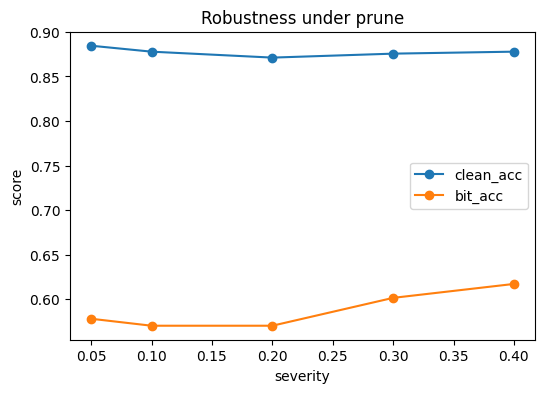

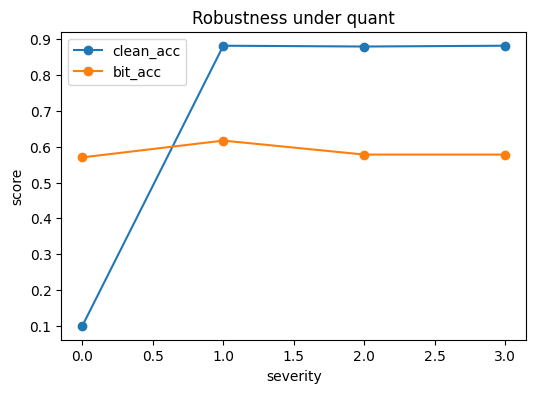

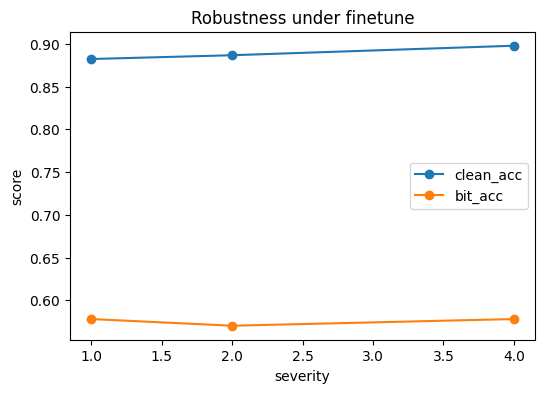

In [13]:
def plot_tradeoff(df, op):
    sub = df[df['op']==op].copy()
    plt.figure(figsize=(6,4))
    plt.plot(sub['level'], sub['clean_acc'], marker='o', label='clean_acc')
    plt.plot(sub['level'], sub['bit_acc'], marker='o', label='bit_acc')
    plt.title(f'Robustness under {op}')
    plt.xlabel('severity')
    plt.ylabel('score')
    plt.legend()
    plt.show()

plot_tradeoff(df, 'prune')
plot_tradeoff(df, 'quant')
plot_tradeoff(df, 'finetune')


## 5. 模型指纹（Fingerprint）：哈希指纹 + 探针集输出摘要

水印用于“归属证明”，指纹用于“版本识别/一致性证明/链路存证”。

### 5.1 权重哈希指纹
将 state_dict 序列化并做 SHA256，可作为最直接的版本标识。
但注意：量化/格式变化会改变哈希，所以可配合“容忍度”版本。

### 5.2 探针集输出摘要（黑盒也可用）
选取一小组探针输入（可公开或内部保管），记录模型输出分布的摘要并哈希。
对比时不需要原训练数据，适合做交付验收或争议仲裁的辅助证据。


In [14]:
def sha256_bytes(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def model_weight_fingerprint(model, round_decimals=None):
    sd = model.state_dict()
    blobs = []
    for k in sorted(sd.keys()):
        t = sd[k].detach().cpu().numpy().astype(np.float32)
        if round_decimals is not None:
            t = np.round(t, round_decimals)
        blobs.append(k.encode('utf-8') + b'\0' + t.tobytes())
    return sha256_bytes(b''.join(blobs))

def probe_output_fingerprint(model, X_probe, round_decimals=4):
    model.eval()
    with torch.no_grad():
        logits = model(X_probe)
        prob = F.softmax(logits, dim=1).cpu().numpy()
    prob = np.round(prob, round_decimals)
    return sha256_bytes(prob.tobytes())

# 探针集：从训练集抽一小段（实际工程可用固定公开样本或内部保管样本）
X_probe = X_train_t[:64]

print('Baseline weight hash:', model_weight_fingerprint(base_model))
print('WM       weight hash:', model_weight_fingerprint(wm_model))

print('Baseline probe hash :', probe_output_fingerprint(base_model, X_probe))
print('WM       probe hash :', probe_output_fingerprint(wm_model, X_probe))

# 容忍度版本：四舍五入后再 hash，可提升对轻微格式变化/量化的稳定性
print('WM weight hash (round=2):', model_weight_fingerprint(wm_model, round_decimals=2))


Baseline weight hash: 408e98097bd7e1a657accf6b7067537dbd60671e23a5df9a807a099bae62de11
WM       weight hash: a5c8a74f68dafba5c94d7963f4170c422e2a26d6da8278616c633e7afa90918b
Baseline probe hash : 72ca86539a253bfb4ea505ee92f5bb8c35ff7de590a7f04b77c5b78f6b73566f
WM       probe hash : fffe36b17b97ef5f5c365644d44d63c59c851549427bf9965753cc04e022c631
WM weight hash (round=2): e9411f3bc24b55a3ce60caed776c6e2edaa9f3a8164efb433b16d61cfcea0cfd


## 6. 使用跟踪机制（工程视角，不绑定具体框架）

水印与指纹解决“归属证明/版本识别”，但在真实应用中还需要“使用跟踪与审计”。

典型机制组合：
- **许可证/令牌绑定**：模型加载前验证 license 文件或签名令牌（离线/在线皆可）
- **API Key + 审计日志**：谁在何时用过模型、查询量、异常模式（结合第10节）
- **响应策略最小化**：默认 label/top-k，避免无必要的高精度 logits
- **争议取证流程**：保留证据链（指纹、日志、交付包哈希、时间戳）

下面给一个“离线课包”可用的最小示例：读取 `artifacts/license.json` 做签名校验占位。
（教学中你可以把它当成“机制演示”，不追求强对抗。）

In [19]:
import json
import hashlib
import hmac
import time
import struct
import base64
from pathlib import Path

# 配置路径
ART_DIR = Path('./artifacts')
LICENSE_PATH = ART_DIR / 'license.json'

# 1. 抵御彩虹表攻击的“盐” (Salt)
# 在实际系统中，这应该是硬件指纹或安装时生成的随机字符串
SYSTEM_SALT = b"USER_UNIQUE_HARDWARE_ID_2023_SALT"

def generate_totp_code(secret: str, interval=30):
    """
    手动实现 TOTP 算法 (RFC 6238 简化版)
    利用当前时间戳生成 6 位动态数字
    """
    # 将密钥转换为字节
    key = secret.encode()
    # 计算当前的时间步长 (每 30 秒变化一次)
    counter = int(time.time() // interval)
    # 将 counter 转为 8 字节的大端格式字节流
    msg = struct.pack(">Q", counter)
    # 使用 HMAC-SHA1 计算哈希 (TOTP 标准通常使用 SHA1)
    h = hmac.new(key, msg, hashlib.sha1).digest()
    # 动态截断 (Dynamic Truncation)
    offset = h[-1] & 0x0F
    code = (struct.unpack(">I", h[offset:offset+4])[0] & 0x7FFFFFFF) % 1000000
    return f"{code:06d}"

def verify_license_secure(path: Path):
    if not path.exists():
        return False, 'license.json not found'
    
    try:
        data = json.loads(path.read_text(encoding='utf-8'))
        
        # 字段提取
        issuer = data.get('issuer')
        expires = data.get('expires')
        signature = data.get('signature')
        otp_secret = data.get('otp_secret') # 2FA 共享密钥

        if not all([issuer, expires, signature, otp_secret]):
            return False, 'Missing fields'

        # --- 1. 防彩虹表验证 (加盐哈希) ---
        # 对发行者和过期时间进行加盐 HMAC 校验
        payload = f"{issuer}|{expires}".encode()
        expected_sig = hmac.new(SYSTEM_SALT, payload, hashlib.sha256).hexdigest()
        
        # 使用 constant_time 比较，防止计时攻击
        if not hmac.compare_digest(signature, expected_sig):
            return False, 'License integrity failed (Invalid signature)'

        # --- 2. 检查过期 ---
        if expires < time.strftime('%Y-%m-%d'):
            return False, 'License expired'

        # --- 3. 双因素认证 (2FA) ---
        print("\n[2FA 验证] 许可证已加密锁定。")
        # 这里的 otp_secret 在实际应用中应由用户在 App 中绑定
        current_valid_code = generate_totp_code(otp_secret)
        
        # 教学演示：打印出来方便你测试，实际应输入
        print(f"(演示提示：当前的动态验证码是: {current_valid_code})")
        
        user_input = input("请输入 6 位动态验证码: ").strip()

        if user_input == current_valid_code:
            return True, f"Verified: {issuer}"
        else:
            return False, "2FA Code incorrect"

    except Exception as e:
        return False, f"System Error: {e}"

# --- 生成演示许可证的逻辑 ---
def create_demo():
    ART_DIR.mkdir(exist_ok=True)
    issuer = "CourseLab"
    expires = "2099-12-31"
    # 2FA 密钥（通常是一个随机字符串）
    otp_secret = "MY_SUPER_SECRET_KEY_FOR_2FA"
    
    # 计算防篡改签名 (加盐)
    payload = f"{issuer}|{expires}".encode()
    sig = hmac.new(SYSTEM_SALT, payload, hashlib.sha256).hexdigest()
    
    lic = {
        "issuer": issuer,
        "expires": expires,
        "signature": sig,
        "otp_secret": otp_secret
    }
    LICENSE_PATH.write_text(json.dumps(lic, indent=4))
    print(f"演示许可证已生成至: {LICENSE_PATH}")

if __name__ == "__main__":
    if not LICENSE_PATH.exists():
        create_demo()
    
    ok, msg = verify_license_secure(LICENSE_PATH)
    print('\nResult:', '✅ PASS' if ok else '❌ FAIL', '|', msg)


[2FA 验证] 许可证已加密锁定。
(演示提示：当前的动态验证码是: 194893)


请输入 6 位动态验证码:  194893



Result: ✅ PASS | Verified: CourseLab


## 7. 本节练习

1) 说明所用水印方案（white-box 权重子集签名）的关键参数：n_bits、lam、target_mag

2) 给出嵌入前后 clean acc 与 bit-acc

3) 完成鲁棒性实验：剪枝/量化/微调至少各 3 个强度点，并画出 trade-off 曲线

4) 给出模型指纹：weight hash、probe hash，并解释它们在证据链中的作用差异

5) 讨论：工程中如何组合“水印 + 指纹 + 审计日志”形成完整版权保护闭环
